# 03 — Controlling for the Car: Teammate- and Constructor-Adjusted Ratings Comparison

Notebook 01 correlated the game's `overall` rating (and sub-attributes) directly against
**raw season points**. That's the most obvious comparison, but it has an obvious confound: F1
results are a joint product of driver skill *and* car/constructor quality, and the two are far
from independent — the fastest cars tend to attract (or be given to) reputationally strong
drivers, and vice versa. A mediocre driver in a dominant car will outscore a great driver in a
backmarker, every time. Raw points can't tell those cases apart.

This notebook re-runs the rating-vs-performance comparison using two **car-adjusted** metrics
that control for machinery by construction:

1. **Teammate delta**: for each race, compare a driver directly against their actual
   team-mate that weekend — same car, same race, same conditions — using both a points
   differential and a finish-position differential. This is the cleanest available control for
   car quality in this dataset.
2. **Constructor points share**: each driver's season points as a fraction of their
   constructor's total season points (i.e., "what share of the team's haul came from this
   seat"), pulled from Jolpica-F1 constructor standings via the new
   `scripts/fetch_constructor_standings.py`.

Both are compared against the raw-points correlations from notebook 01 side by side, to see how
much of the original result was really "driver skill" versus "which car they were in."

As always: n is ~19–22 drivers, one full season (2025) and one partial season (2026, 9 rounds).
Descriptive only.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.append(os.path.join(os.getcwd(), "..", "scripts"))
from build_dataset import last_name

RAW_DIR = os.path.join("..", "data", "raw")
PROC_DIR = os.path.join("..", "data", "processed")

pd.set_option("display.width", 120)
plt.rcParams["figure.dpi"] = 110

ATTRS = ["overall", "experience", "racecraft", "awareness", "pace"]

## Load data

Note a wrinkle that matters for a "same car" comparison: the ratings CSV's static `team` column
reflects each driver's **launch-time (mid-2025)** seat, which is not always their actual seat in
a given season's races -- e.g. Isack Hadjar and Liam Lawson swapped between Red Bull and the
sister Racing Bulls/RB F1 Team squad between 2025 and 2026, and 2025 itself had mid-season
driver changes (Jack Doohan replaced by Franco Colapinto at Alpine after round 6; Sergio Perez
and Valtteri Bottas weren't on the 2025 grid at all). To pair teammates correctly *per season*,
we use the season-specific `constructor` field recorded on each individual race result -- not
the ratings table's static `team` column.

In [2]:
ratings = pd.read_csv(os.path.join(PROC_DIR, "f1_ratings_vs_results.csv"))
ratings["name_key"] = ratings["driver"].map(last_name)

race_all = pd.read_csv(os.path.join(RAW_DIR, "f1_race_results.csv"))
constructors_2025 = pd.read_csv(os.path.join(RAW_DIR, "f1_constructorstandings_2025.csv"))
constructors_2026 = pd.read_csv(os.path.join(RAW_DIR, "f1_constructorstandings_2026.csv"))

print(f"{len(ratings)} rated drivers")
print(f"2025 constructor standings: {len(constructors_2025)} teams, "
      f"{constructors_2025['points'].sum():.0f} total points")
print(f"2026 constructor standings (partial, 9 rounds): {len(constructors_2026)} teams, "
      f"{constructors_2026['points'].sum():.0f} total points")

22 rated drivers
2025 constructor standings: 10 teams, 2640 total points
2026 constructor standings (partial, 9 rounds): 11 teams, 1053 total points


## Metric 1 — Teammate delta (same-car comparison)

For every (round, constructor) pair with exactly two classified drivers, compute each driver's
points and finish position relative to their team-mate that race:

- `delta_points = driver_points - teammate_points`
- `delta_position = teammate_finish_position - driver_finish_position` (positive = driver
  finished ahead of their team-mate)

Then average both across all rounds each driver actually had a same-race team-mate, per
season.

In [3]:
def teammate_deltas(season):
    df = race_all[race_all["season"] == season].copy()
    df["name_key"] = df["family_name"].map(last_name)
    rows = []
    for (rnd, constructor), grp in df.groupby(["round", "constructor"]):
        if len(grp) != 2:
            continue  # skip rounds where a team didn't field exactly 2 classified cars
        a, b = grp.iloc[0], grp.iloc[1]
        rows.append({"name_key": a["name_key"], "delta_points": a["points"] - b["points"],
                      "delta_position": b["position"] - a["position"]})
        rows.append({"name_key": b["name_key"], "delta_points": b["points"] - a["points"],
                      "delta_position": a["position"] - b["position"]})
    long = pd.DataFrame(rows)
    return (
        long.groupby("name_key")
        .agg(avg_teammate_delta_points=("delta_points", "mean"),
             avg_teammate_delta_position=("delta_position", "mean"),
             n_rounds_with_teammate=("delta_points", "count"))
        .reset_index()
    )


teammate_2025 = teammate_deltas(2025)
teammate_2026 = teammate_deltas(2026)

merged_2025 = ratings.merge(teammate_2025, on="name_key", how="inner")
merged_2026 = ratings.merge(teammate_2026, on="name_key", how="inner")

print(f"2025: {len(merged_2025)} of {len(ratings)} rated drivers had a same-race teammate to compare against")
print(f"2026: {len(merged_2026)} of {len(ratings)} rated drivers had a same-race teammate to compare against")
merged_2025[["driver", "team", "avg_teammate_delta_points", "avg_teammate_delta_position",
             "n_rounds_with_teammate"]].sort_values("avg_teammate_delta_points", ascending=False)

2025: 19 of 22 rated drivers had a same-race teammate to compare against
2026: 22 of 22 rated drivers had a same-race teammate to compare against


,driver,team,avg_teammate_delta_points,avg_teammate_delta_position,n_rounds_with_teammate
0,Max Verstappen,Red Bull Racing,15.333333,8.875000,24
2,George Russell,Mercedes,6.416667,5.291667,24
3,Charles Leclerc,Ferrari,3.750000,1.750000,24
9,Nico Hulkenberg,Audi,1.333333,1.458333,24
6,Fernando Alonso,Aston Martin,0.869565,1.695652,23
10,Pierre Gasly,Alpine,0.833333,1.541667,24
8,Alexander Albon,Williams,0.666667,1.125000,24
1,Lando Norris,McLaren,0.541667,-0.041667,24
13,Isack Hadjar,Racing Bulls,0.500000,1.041667,24
14,Oliver Bearman,Haas,0.208333,0.708333,24


## Metric 2 — Constructor points share

Each driver's season points as a fraction of their constructor's total season points. A driver
who scores, say, 60% of their team's points (versus their team-mate's 40%) is outperforming the
car itself, regardless of whether the car was good or bad overall.

In [4]:
def add_constructor_share(df, season, constructor_standings):
    col_constructor = f"constructor_{season}"
    col_points = f"points_{season}"
    standings = constructor_standings.rename(
        columns={"points": f"team_points_{season}", "constructor": col_constructor}
    )[[col_constructor, f"team_points_{season}"]]
    out = df.merge(standings, on=col_constructor, how="left")
    out[f"points_share_{season}"] = out[col_points] / out[f"team_points_{season}"]
    return out


ratings_with_share = add_constructor_share(ratings, 2025, constructors_2025)
ratings_with_share = add_constructor_share(ratings_with_share, 2026, constructors_2026)

share_2025 = ratings_with_share.dropna(subset=["points_share_2025"])
share_2026 = ratings_with_share.dropna(subset=["points_share_2026"])
print(f"2025: {len(share_2025)} drivers with a valid constructor points share")
print(f"2026: {len(share_2026)} drivers with a valid constructor points share")

share_2025[["driver", "team", "points_2025", "team_points_2025", "points_share_2025"]] \
    .sort_values("points_share_2025", ascending=False)

2025: 19 drivers with a valid constructor points share
2026: 20 drivers with a valid constructor points share


,driver,team,points_2025,team_points_2025,points_share_2025
11,Pierre Gasly,Alpine,22.0,22.0,1.000000
0,Max Verstappen,Red Bull Racing,421.0,451.0,0.933481
10,Nico Hulkenberg,Audi,51.0,70.0,0.728571
2,George Russell,Mercedes,319.0,469.0,0.680171
6,Fernando Alonso,Aston Martin,56.0,89.0,0.629213
3,Charles Leclerc,Ferrari,242.0,398.0,0.608040
15,Isack Hadjar,Racing Bulls,51.0,92.0,0.554348
8,Alexander Albon,Williams,73.0,137.0,0.532847
16,Oliver Bearman,Haas,41.0,79.0,0.518987
1,Lando Norris,McLaren,423.0,833.0,0.507803


## Side-by-side: raw points vs. car-adjusted metrics

For each attribute, compare its Pearson correlation against three targets:
- **raw season points** (notebook 01's original metric — includes the car-quality confound)
- **teammate points delta** (car-adjusted)
- **constructor points share** (car-adjusted)

In [5]:
def comparison_table(season):
    raw_col = f"points_{season}"
    raw_df = ratings.dropna(subset=[raw_col])
    tm_df = teammate_2025 if season == 2025 else teammate_2026
    tm_df = ratings.merge(tm_df, on="name_key", how="inner")
    sh_df = share_2025 if season == 2025 else share_2026

    rows = []
    for attr in ATTRS:
        r_raw, p_raw = stats.pearsonr(raw_df[attr], raw_df[raw_col])
        r_tm, p_tm = stats.pearsonr(tm_df[attr], tm_df["avg_teammate_delta_points"])
        r_sh, p_sh = stats.pearsonr(sh_df[attr], sh_df[f"points_share_{season}"])
        rows.append({
            "attribute": attr,
            "r_raw_points": r_raw, "p_raw_points": p_raw, "n_raw": len(raw_df),
            "r_teammate_delta": r_tm, "p_teammate_delta": p_tm, "n_teammate": len(tm_df),
            "r_constructor_share": r_sh, "p_constructor_share": p_sh, "n_share": len(sh_df),
        })
    return pd.DataFrame(rows)


print("=== 2025 (full season) ===")
table_2025 = comparison_table(2025)
display(table_2025.round(3))

print("\n=== 2026 (partial season, 9 rounds) ===")
table_2026 = comparison_table(2026)
display(table_2026.round(3))

=== 2025 (full season) ===


,attribute,r_raw_points,p_raw_points,n_raw,r_teammate_delta,p_teammate_delta,n_teammate,r_constructor_share,p_constructor_share,n_share
0,overall,0.804,0.000,19,0.517,0.023,19,0.626,0.004,19
1,experience,0.143,0.559,19,0.243,0.315,19,0.479,0.038,19
2,racecraft,0.725,0.000,19,0.479,0.038,19,0.593,0.007,19
3,awareness,0.476,0.039,19,0.416,0.076,19,0.466,0.044,19
4,pace,0.865,0.000,19,0.561,0.012,19,0.612,0.005,19



=== 2026 (partial season, 9 rounds) ===


,attribute,r_raw_points,p_raw_points,n_raw,r_teammate_delta,p_teammate_delta,n_teammate,r_constructor_share,p_constructor_share,n_share
0,overall,0.481,0.024,22,0.096,0.671,22,0.228,0.333,20
1,experience,0.023,0.919,22,0.226,0.312,22,0.082,0.732,20
2,racecraft,0.481,0.023,22,0.120,0.594,22,0.267,0.254,20
3,awareness,0.321,0.146,22,-0.135,0.548,22,-0.066,0.781,20
4,pace,0.541,0.009,22,0.038,0.867,22,0.198,0.403,20


**This is the headline finding.** In the complete 2025 season, `overall`/`pace`/`racecraft`
correlate strongly with raw points (r ≈ 0.72–0.87, all p < 0.001) — but a meaningful chunk of
that is the car-quality confound baked into raw scoring. Once car quality is controlled for via
same-race teammate comparison or constructor points share, the correlations **weaken
substantially but do not disappear**: `overall`, `pace`, and `racecraft` still correlate at
r ≈ 0.48–0.63 with both car-adjusted metrics, and most remain statistically significant at
p < 0.05 despite the smaller effective sample from teammate pairing.

That's a materially more honest — and more reassuring — answer than notebook 01's raw-points
comparison alone would suggest: the game's rating isn't *purely* tracking "who's in the best
car," there's a genuine skill-tracking signal that survives controlling for machinery, even if
it's weaker than the uncontrolled numbers imply.

**In the 2026 partial season, that signal is gone.** None of the car-adjusted correlations
reach significance (p mostly > 0.25), even though the raw-points correlations are still
moderately positive (r ≈ 0.45–0.54, matching notebook 01). This is a good illustration of why
the car-adjusted view matters: raw points in the 9-round 2026 sample would suggest the ratings
are tracking performance about as well as in 2025, but that reading is likely still dominated by
which car a driver is in this early in the season, with the driver-skill signal too noisy to
separate out yet at this sample size.

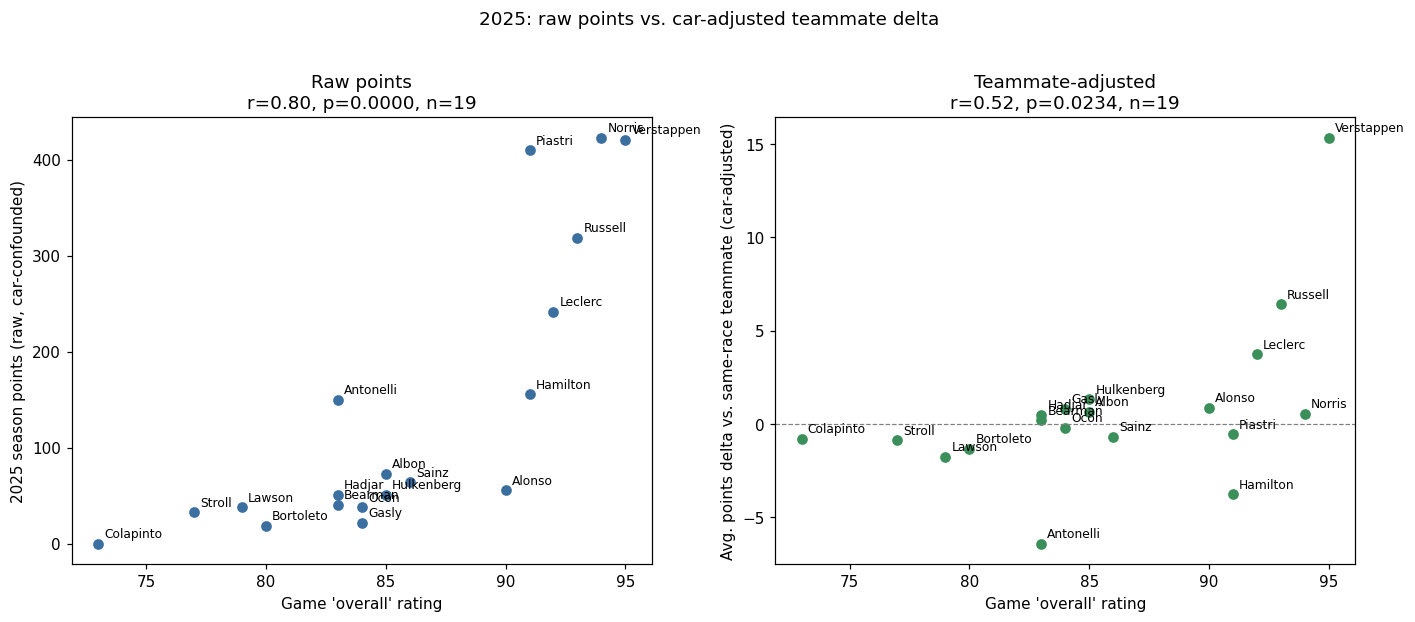

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ax = axes[0]
d = ratings.dropna(subset=["points_2025"])
ax.scatter(d["overall"], d["points_2025"], color="#3b6fa0")
for _, row in d.iterrows():
    ax.annotate(row["driver"].split(" ")[-1], (row["overall"], row["points_2025"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
r, p = stats.pearsonr(d["overall"], d["points_2025"])
ax.set_xlabel("Game 'overall' rating")
ax.set_ylabel("2025 season points (raw, car-confounded)")
ax.set_title(f"Raw points\nr={r:.2f}, p={p:.4f}, n={len(d)}")

ax = axes[1]
d2 = ratings.merge(teammate_2025, on="name_key", how="inner")
ax.scatter(d2["overall"], d2["avg_teammate_delta_points"], color="#3b8f5a")
for _, row in d2.iterrows():
    ax.annotate(row["driver"].split(" ")[-1], (row["overall"], row["avg_teammate_delta_points"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
r2, p2 = stats.pearsonr(d2["overall"], d2["avg_teammate_delta_points"])
ax.set_xlabel("Game 'overall' rating")
ax.set_ylabel("Avg. points delta vs. same-race teammate (car-adjusted)")
ax.set_title(f"Teammate-adjusted\nr={r2:.2f}, p={p2:.4f}, n={len(d2)}")

fig.suptitle("2025: raw points vs. car-adjusted teammate delta", y=1.02)
fig.tight_layout()
fig.savefig("raw_vs_car_adjusted_2025.png", dpi=130, bbox_inches="tight")
plt.show()

## Over/under-rated once the car is controlled for

Notebook 01's rank-delta table compared each driver's rank by `overall` against their rank by
raw season points. Repeating that here using the **teammate-adjusted points delta** instead
changes which drivers show up as over- or under-rated, since it strips out "drives a great/bad
car" as an explanation.

In [7]:
def rank_deltas(df, rating_col, real_col, season_label):
    out = df[["driver", "team", rating_col, real_col]].copy()
    out["game_rank"] = out[rating_col].rank(ascending=False, method="min")
    out["real_rank"] = out[real_col].rank(ascending=False, method="min")
    out["delta"] = out["game_rank"] - out["real_rank"]
    out["season"] = season_label
    return out.sort_values("delta")


rd_2025 = rank_deltas(merged_2025, "overall", "avg_teammate_delta_points", "2025 (car-adjusted)")
print("Most under-rated relative to teammate-adjusted performance (2025):")
display(rd_2025.head(6)[["driver", "team", "overall", "avg_teammate_delta_points", "game_rank", "real_rank", "delta"]])

print("\nMost over-rated relative to teammate-adjusted performance (2025):")
display(rd_2025.tail(6)[["driver", "team", "overall", "avg_teammate_delta_points", "game_rank", "real_rank", "delta"]])

Most under-rated relative to teammate-adjusted performance (2025):


,driver,team,overall,avg_teammate_delta_points,game_rank,real_rank,delta
4,Lewis Hamilton,Ferrari,91,-3.750000,5.0,18.0,-13.0
5,Oscar Piastri,McLaren,91,-0.541667,5.0,12.0,-7.0
1,Lando Norris,McLaren,94,0.541667,2.0,8.0,-6.0
12,Kimi Antonelli,Mercedes,83,-6.416667,13.0,19.0,-6.0
7,Carlos Sainz,Williams,86,-0.666667,8.0,13.0,-5.0
0,Max Verstappen,Red Bull Racing,95,15.333333,1.0,1.0,0.0



Most over-rated relative to teammate-adjusted performance (2025):


,driver,team,overall,avg_teammate_delta_points,game_rank,real_rank,delta
14,Oliver Bearman,Haas,83,0.208333,13.0,10.0,3.0
17,Lance Stroll,Aston Martin,77,-0.869565,18.0,15.0,3.0
13,Isack Hadjar,Racing Bulls,83,0.500000,13.0,9.0,4.0
9,Nico Hulkenberg,Audi,85,1.333333,9.0,4.0,5.0
10,Pierre Gasly,Alpine,84,0.833333,11.0,6.0,5.0
18,Franco Colapinto,Alpine,73,-0.777778,19.0,14.0,5.0


## Takeaways and honest limitations

- **Raw points overstate how well the game's rating tracks driver skill.** In the full 2025
  season, `overall`/`pace`/`racecraft` correlate with raw points at r ≈ 0.72–0.87, but a real
  chunk of that is car quality. Controlling for car via same-race teammate delta or constructor
  points share brings those correlations down to r ≈ 0.48–0.63 — still positive and (mostly)
  still significant, but visibly weaker.
- **The signal that survives car-adjustment is the more meaningful one.** That correlations
  don't collapse to zero after controlling for machinery is the more reassuring reading here:
  it suggests the rating isn't just a proxy for "who's in the best car," even though the raw
  numbers alone can't distinguish the two.
- **This doesn't replicate in the 2026 partial season.** None of the car-adjusted metrics are
  significant through 9 rounds, even though raw points still look moderately correlated —
  a caution that early-season raw-points correlations can look similar to a full season's while
  actually still being dominated by car quality, not driver skill, at low round counts.
- **Teammate-delta relies on real-world mid-season driver changes** (Doohan/Colapinto at Alpine
  in 2025; Perez, Bottas, and Lindblad joining the 2026 grid; the Hadjar/Lawson seat swap between
  Red Bull and its sister team) which reduces the number of *shared* races some drivers have with
  a stable teammate, and means "teammate" isn't always the same person for all of a driver's
  races in a season — this is handled per-round (each round's actual pairing is used), but it
  does add noise relative to a hypothetical season with fixed, stable lineups.
- **n remains small** (19–22 drivers with a valid teammate comparison; even fewer for the
  constructor-share metric where a season total maps to a single number per driver). None of
  these correlations should be read as more than descriptive, especially the 2026 partial-season
  ones.
- **Constructor points share and teammate delta measure closely related but not identical
  things** — share is a full-season aggregate relative to the *team's* total, while teammate
  delta is a per-race, per-teammate comparison. That both point in the same direction in 2025 and
  both lose significance in 2026 is a useful cross-check, but they're not fully independent
  pieces of evidence.